Implementing TunED as in the paper, checking for the driver variable between % of escape and shelter distance in the escape/homing period
Comparison between real and predicted is done using euclidean distance
Stats are done using bootstrap with sampling with replacement

In [1]:
from behave_analysis.database.Experiments.JAL003_ex import JAL3_25aug, JAL3_1sept, JAL3_4sept, JAL3_7sept, JAL3_22aug

from behave_analysis.database.Experiments.JAL004_ex import JAL4_3rdSept, JAL4_19thSept, JAL4_11thSept, JAL4_28aug

from behave_analysis.database.Experiments.JAL005_ex import JAL005_8thSept, JAL005_21stSept, JAL005_5thSept

from behave_analysis.database.Experiments.JAL006_ex import JAL6_flip3_18mar, JAL6_flip7_1apr, JAL6_28mar, JAL6_flip4_21mar, JAL6_flip5_25mar

from behave_analysis.database.Experiments.JAL007_ex import JAL7_sesh8_9apr, JAL7_sesh9_16apr, JAL7_flip5_22mar, JAL7_flip2_12mar, JAL7_23apr

from behave_analysis.database.Experiments.JAL008_ex import JAL8_flip3_7may, JAL8_flip1_25apr, JAL8_flip2_29apr, JAL8_flip4_10may, JAL8_14may

# JAL3_7sept, JAL3_4sept, JAL3_1sept, JAL3_25aug, JAL3_22aug,
# "JAL3_7sept", "JAL3_4sept", "JAL3_1sept", "JAL3_25aug", "JAL3_22aug",

experiments_objects = [JAL4_3rdSept, JAL4_19thSept, JAL4_28aug, JAL4_11thSept,
JAL005_8thSept, JAL005_21stSept, # JAL005_5thSept this one doesn't flip, but can be used as first barrier appearance
JAL6_28mar, JAL6_flip4_21mar, JAL6_flip3_18mar, JAL6_flip5_25mar, # (unmatched number of neurons and cluster ids) # JAL6_flip7_1apr, # this session is sus
JAL7_sesh8_9apr, JAL7_flip5_22mar, JAL7_flip2_12mar, JAL7_sesh9_16apr, JAL7_23apr,
JAL8_flip1_25apr,JAL8_flip2_29apr, JAL8_flip3_7may, JAL8_14may, JAL8_flip4_10may]

In [2]:
%load_ext autoreload
from behave_analysis.utils.creating_directories import make_directory
from JR_test_scripts.escape.escape_utils import load, load_homing, compute_dist_shelt, firing_by_bin_median_numba
from JR_test_scripts.escape.escape_data_loading_funcs import extract_homing_and_escape_periods, build_shift_vector
from JR_test_scripts.escape.escape_tuning_funcs import nan_winsorized_mean_2d

import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import binned_statistic, norm
from scipy.ndimage import gaussian_filter1d
from scipy.stats.mstats import winsorize
from matplotlib_venn import venn3
from sklearn.metrics.pairwise import cosine_similarity

%matplotlib inline

In [3]:
"""All the needed functions"""

def avg_tuning_method_TunED(X, y, Nbins, n_neur):
    """
    Computes tuning curves across conditions and neurons, including mean firing rate, 
    variance + (mean^2), and number of samples per bin.

    RETURNS:
        fr_full:    (n_cond, n_neur, bins) - Average firing rate across trials.
    """
    # Nbins = 13
    firing_hist = np.full((n_neur, Nbins), np.nan)
    # bin angles
    for i in range(n_neur):
        firing_hist[i, :] = firing_by_angle_bin(y, X[:, i], Nbins)

    return firing_hist

def firing_by_angle_bin(angles, neural_activity, nbins):
    angles_firing = np.zeros(nbins)
    unique_groups, group_counts = np.unique(angles, return_counts=True)
    group_sums = np.bincount(angles, weights=neural_activity)
    angles_firing[unique_groups] = group_sums[unique_groups] / group_counts
    return angles_firing

def tuning_method_TunED(var, escape_matrix, cond, h_start, bins, n_cond, n_neur):
    """
    Computes tuning curves across conditions and neurons, including mean firing rate, 
    variance + (mean^2), and number of samples per bin.

    RETURNS:
        fr_full:    (n_cond, n_neur, bins) - Average firing rate across trials.
    """
    # Initialize output variables
    fr_full = np.zeros((n_cond, n_neur, bins)) # conditions x neurons x n_bins
    c = [len([x for x in h_start if cond[x] == i]) for i in range(n_cond)] # what is the max number of trials across all conditions

    # Step 1: Compute firing per bin per trial
    for i in range(n_cond):  # Loop over conditions
        # Find trial indices for this condition
        cond_start = [x for x in h_start if cond[x] == int(i)]
        cond_start.append(np.sum(cond == int(i)))

        for j, n in enumerate(escape_matrix):  # Loop over neurons
            mat = np.full((max(c),bins), np.nan) # conditions x neurons x trials x bins
            for tr, _ in enumerate(cond_start[:-1]):
                neur = n[cond_start[tr]:cond_start[tr+1]]
                v = var[cond_start[tr]:cond_start[tr+1]]
                
                # Compute firing per bin (without removing empty bins)
                mat[tr,:] = firing_by_bin_median_numba(v.astype(int), neur, bins, remove_empty=False)

            # Step 2: Compute winsorized mean across trials
            all_nan_cols = np.all(np.isnan(mat), axis=0)
            smoothed_firing_rates = np.full(bins, np.nan)

            if np.any(~all_nan_cols):  # If at least one non-NaN column exists
                valid_data = mat[:, ~all_nan_cols]  # Exclude all-NaN columns
                
                # Compute winsorized mean
                smoothed_firing_rates[~all_nan_cols] = nan_winsorized_mean_2d(valid_data, limits=(.15, .15), axis=0)

            # Store results
            fr_full[i, j, :] = smoothed_firing_rates

    return fr_full

def estimate_p_conditional_LF(v1, v2, bin_edges):

    # Compute joint histogram P(v1, v2)
    joint_prob, _, _ = np.histogram2d(v1, v2, bins=[bin_edges, bin_edges], density=True)

    # Compute marginal probability P(v2)
    Pv1 = np.sum(joint_prob, axis=0)
    Pv2 = np.sum(joint_prob, axis=1)

    # Compute conditional probability P(v1 | v2) (avoid division by zero)
    Pv2_v1 = joint_prob / (np.ones(len(Pv2)).reshape(-1, 1) * (Pv1 + 1e-8))
    Pv1_v2 = joint_prob.T / (np.ones(len(Pv1)).reshape(-1, 1) * (Pv2 + 1e-8))  # P(v1|v2)

    return Pv2_v1, Pv1_v2

def compute_expected_tuning_LF(mu_v1, p_v1_given_v2):
    """INPUTS: mu_v1: mean tuning curve for v1
               p_v1_given_v2: conditional probability of v1 given v2"""
    Nbins_x = p_v1_given_v2.shape[1]
    mu_NH_v2 = np.sum((mu_v1[:, None] @ np.ones((1, Nbins_x))) * p_v1_given_v2, axis=0) # Turn ty_y into a column vector and multiply by Py_x
    return mu_NH_v2

def compare_curves(mu_v1, mu_v2, mu_NH_v1, mu_NH_v2):
    """Compute the difference in euclidean distance between real and expected tuning curves"""
    
    dv1 = np.sqrt(np.sum((mu_v1 - mu_NH_v1)**2))
    dv2 = np.sqrt(np.sum((mu_v2 - mu_NH_v2)**2))

    # Store difference
    dv1_minus_dv2 = dv1 - dv2

    return dv1_minus_dv2

def compare_curves_cosim(mu_v1, mu_v2, mu_NH_v1, mu_NH_v2):

    cosim1 = cosine_similarity(mu_v1.reshape(1,-1), mu_NH_v1.reshape(1,-1))[0][0]
    cosim2 = cosine_similarity(mu_v2.reshape(1,-1), mu_NH_v2.reshape(1,-1))[0][0]

    cosim1_minus_cosim2 = cosim1 - cosim2

    return cosim1_minus_cosim2

def venn_diagram(dv1_minus_dv2, dv1_minus_dv2_dist, sig_cells, exp_sig_cells, c_names, savepath):
    """Venn diagram"""

    fig, axs = plt.subplots(2,3,figsize=(9, 6))
    for c in range(dv1_minus_dv2.shape[1]):
        dist_this_c = dv1_minus_dv2_dist[:,c,:]
        lower_percentile, upper_percentile = np.percentile(dist_this_c, [2.5, 97.5], axis = 0)
        v1_sig = (lower_percentile > 0) & (upper_percentile > 0)
        v2_sig = (lower_percentile < 0) & (upper_percentile < 0)
        untuned = ~v1_sig & ~v2_sig
        # show how many are still %escape
        third = v1_sig
        # Compute Set Sizes
        A = np.sum((sig_cells[:, c] == True) & (exp_sig_cells[:, c] == False) & (third == False))  # V1 only
        B = np.sum((sig_cells[:, c] == False) & (exp_sig_cells[:, c] == True) & (third == False))  # V2 only
        C = np.sum((sig_cells[:, c] == False) & (exp_sig_cells[:, c] == False) & (third == True))  # V1 regressed
        AB = np.sum((sig_cells[:, c] == True) & (exp_sig_cells[:, c] == True) & (third == False))  # Both V1 and V2
        AC = np.sum((sig_cells[:, c] == True) & (exp_sig_cells[:, c] == False) & (third == True))  # Both V1 and V1 regressed
        BC = np.sum((sig_cells[:, c] == False) & (exp_sig_cells[:, c] == True) & (third == True))  # Both V2 and V1 regressed
        ABC = np.sum((sig_cells[:, c] == True) & (exp_sig_cells[:, c] == True) & (third == True))  # All three

        # Create Venn Diagram
        venn3(subsets=(A, B, AB, C, AC, BC, ABC), 
            set_labels=(r'%escape', 'shelt_dist', r'% escape tunED'), 
            set_colors=('blue', 'red', 'green'),
            alpha=0.5,
            ax=axs[0,c])
        axs[0,c].set_title('Overlap of Significant Cells \nin ' + c_names[c])

        # show how many are still %escape
        third = v2_sig
        # Compute Set Sizes
        A = np.sum((sig_cells[:, c] == True) & (exp_sig_cells[:, c] == False) & (third == False))  # V1 only
        B = np.sum((sig_cells[:, c] == False) & (exp_sig_cells[:, c] == True) & (third == False))  # V2 only
        C = np.sum((sig_cells[:, c] == False) & (exp_sig_cells[:, c] == False) & (third == True))  # V1 regressed
        AB = np.sum((sig_cells[:, c] == True) & (exp_sig_cells[:, c] == True) & (third == False))  # Both V1 and V2
        AC = np.sum((sig_cells[:, c] == True) & (exp_sig_cells[:, c] == False) & (third == True))  # Both V1 and V1 regressed
        BC = np.sum((sig_cells[:, c] == False) & (exp_sig_cells[:, c] == True) & (third == True))  # Both V2 and V1 regressed
        ABC = np.sum((sig_cells[:, c] == True) & (exp_sig_cells[:, c] == True) & (third == True))  # All three

        # Create Venn Diagram
        venn3(subsets=(A, B, AB, C, AC, BC, ABC), 
            set_labels=(r'%escape', 'shelt_dist', r'shelt dist tunED'), 
            set_colors=('blue', 'red', 'green'),
            alpha=0.5,
            ax=axs[1,c])

    plt.tight_layout()
    fig.savefig(savepath)
    plt.close()

In [7]:
"""Load in and extract all necessary data"""

%autoreload 2

for exp in experiments_objects[7:8]:
    # 1. load in distance to shelter in escape/homing tuning curve
    comp = 'bird_dist_shelter'
    nickname = exp.nick_name + '_' + exp.experiment_date
    exp_nickname = exp.nick_name + '_' + exp.experiment_date + '_' + comp
    dump_path = make_directory("Z:/Jasmine_Laurence/summary_plots/tuning_curves/")
    saving_file = dump_path + exp_nickname + '_ProperTuning.npz'
    data = np.load(saving_file)

    # pull out the params
    exp_params_real = data['params_real']
    exp_params_shifts = data['params_shifts']

    # create vector of which cells are sig to distance in exploration
    # find sig. cells that have gaussian amplitude greater than 95th perc of linear shifts
    exp_sig_cells = exp_params_real[:,:,0] > np.nanpercentile(exp_params_shifts[:,:,:,0], 95, axis = 0)

    # 2. load in %escape in homing/escape tuning curve
    comp = 'escape'
    exp_nickname = exp.nick_name + '_' + exp.experiment_date + '_' + comp
    dump_path = make_directory("Z:/Jasmine_Laurence/summary_plots/tuning_curves/")
    saving_file = dump_path + exp_nickname + '_ProperTuning.npz'
    data = np.load(saving_file)

    params_real = data['params_real']
    params_shifts = data['params_shifts']

    # create vector of which cells are sig to fraction of escape
    # find sig. cells that have gaussian amplitude greater than 95th perc of linear shifts
    sig_cells = params_real[:,:,0] > np.nanpercentile(params_shifts[:,:,:,0], 95, axis = 0)

    # 3. load in neural data
    # session, frame_by_cluster_matrix, behave, y_pos, x_pos, bar, barflip, escape, outofshelter = load(exp)
    # ons, offs, homie = load_homing(session, len(behave))
    fcm = gaussian_filter1d(frame_by_cluster_matrix, 2, axis = 0)

    # 4. extract escape matrix with respect to 'escape'
    comp = 'escape'
    frac_escape, escape_matrix, cond, h_start = extract_homing_and_escape_periods(session, 
                                                                                    fcm, 
                                                                                    behave, 
                                                                                    y_pos, x_pos, 
                                                                                    bar, 
                                                                                    barflip, 
                                                                                    comp, 
                                                                                    ons, offs, 
                                                                                    no_stationary = False, 
                                                                                    return_escape = False,
                                                                                    zscore = False)

    # initialize vars
    bins_escape = int(np.amax(frac_escape)+1)
    n_neur = frame_by_cluster_matrix.shape[1]
    n_cond = len(np.unique(cond))

    # 5. extract neural data with respect to 'distance to shelter'
    comp = 'bird_dist_shelter'
    full_bird_dist_shelt = compute_dist_shelt(x_pos, y_pos, cond=np.zeros_like(x_pos), session=session)
    bin_size = np.amax(full_bird_dist_shelt)/(bins_escape-1)
    shelt_dist, _, _, _ = extract_homing_and_escape_periods(session, 
                                                            fcm, 
                                                            behave, 
                                                            y_pos, x_pos, 
                                                            bar, 
                                                            barflip, 
                                                            comp, 
                                                            ons, offs, 
                                                            no_stationary = False, 
                                                            return_escape = False,
                                                            zscore = False,
                                                            bin_size = bin_size)

    # pull out only homings that are 'complete' (north of barrier to shelter)
    h_end = np.append(h_start, len(cond))
    h_start = np.append(0, h_start)

    X, _, _, _, _ = extract_homing_and_escape_periods(session, 
                                                        fcm, 
                                                        x_pos, 
                                                        y_pos, x_pos, 
                                                        bar, 
                                                        barflip, 
                                                        'speed', 
                                                        ons, offs, 
                                                        no_stationary = False, 
                                                        return_escape = True,
                                                        zscore = False)

    Y, _, _, _, _ = extract_homing_and_escape_periods(session, 
                                                        fcm, 
                                                        y_pos, 
                                                        y_pos, x_pos, 
                                                        bar, 
                                                        barflip, 
                                                        'speed', 
                                                        ons, offs, 
                                                        no_stationary = False, 
                                                        return_escape = True,
                                                        zscore = False)

    homies = np.array(h_start)
    homies_to_keep = np.full(len(homies), False)
    for i, h in enumerate(homies):
        c = int(cond[h])
        if c == 0:
            homies_to_keep[i] = True
        else:
            y_points = Y[h:h_end[i]]
            if (y_points[-1] > 550) & (y_points[0] < 512): # homings that end south of the barrier and start north of the barrier
                homies_to_keep[i] = True
    
    h_start = h_start[homies_to_keep]
    h_end = h_end[homies_to_keep]

    # remake variables: escape matrix, shelt_dist, frac_escape, cond
    new_em = np.full((n_neur, np.sum(h_end - h_start)), np.nan)
    new_shelt_dist = np.full(np.sum(h_end - h_start), np.nan)
    new_escape = np.full(np.sum(h_end - h_start), np.nan)
    new_cond = np.full(np.sum(h_end - h_start), np.nan)

    counter = 0
    for i, (start, end) in enumerate(zip(h_start, h_end)):
        new_em[:,counter:counter+(end-start)] = escape_matrix[:,start:end]
        new_shelt_dist[counter:counter+(end-start)] = shelt_dist[start:end]
        new_escape[counter:counter+(end-start)] = frac_escape[start:end]
        new_cond[counter:counter+(end-start)] = cond[start:end]
        counter += (end-start)

    cond = new_cond
    frac_escape = new_escape
    escape_matrix = new_em
    shelt_dist = new_shelt_dist

    # 6. TunED analysis
    Nbins = bins_escape
    # fr_esc = tuning_method_TunED(frac_escape, escape_matrix, cond, h_start, Nbins, n_cond, n_neur)
    # fr_dist = tuning_method_TunED(shelt_dist, escape_matrix, cond, h_start, Nbins, n_cond, n_neur)
    fr_esc = np.full((n_cond, n_neur, Nbins), np.nan)
    fr_dist = np.full((n_cond, n_neur, Nbins), np.nan)

    # perform tuned on cells of interest
    dv1_minus_dv2 = np.full((n_neur,n_cond), np.nan)
    cosim1_minus_cosim2 = np.full((n_neur,n_cond), np.nan)
    mu_NH_v2 = np.full((n_neur,n_cond, Nbins), np.nan)
    mu_NH_v1 = np.full((n_neur,n_cond, Nbins), np.nan)

    for c in [0,1,2]: # which condition do we want to look at
        
        fr_esc[c,:,:] = avg_tuning_method_TunED(escape_matrix[:,cond == c].T, frac_escape[cond == c].astype(int), Nbins, n_neur)
        fr_dist[c,:,:] = avg_tuning_method_TunED(escape_matrix[:,cond == c].T, shelt_dist[cond == c].astype(int), Nbins, n_neur)

        for idx in range(n_neur):
            # Step 1: Real Observed Tuning Curves and their variance
            mu_v1 = fr_esc[c, idx,:]
            mu_v2 = fr_dist[c, idx,:]

            # Step 3: Estimate P(v1 | v2) and P(v2 | v1)
            v1 = frac_escape[cond == c]
            v2 = shelt_dist[cond == c]
            bin_edges = np.arange(Nbins + 1)

            Pv2_v1, Pv1_v2 = estimate_p_conditional_LF(v1, v2, bin_edges)

            # Step 4: Compute Expected Tuning Curve Under NH

            mu_NH_v2[idx,c,:] = compute_expected_tuning_LF(mu_v1, Pv1_v2) # tuning to v2 given that driver is v1
            mu_NH_v1[idx,c,:] = compute_expected_tuning_LF(mu_v2, Pv2_v1) # tuning to v1 given that driver is v2

            # Step 5: Compare Actual vs Expected Tuning for significance
            dv1_minus_dv2[idx, c] = compare_curves(mu_v1, mu_v2, mu_NH_v1[idx,c,:], mu_NH_v2[idx,c,:])
            cosim1_minus_cosim2[idx, c] = compare_curves_cosim(mu_v1, mu_v2, mu_NH_v1[idx,c,:], mu_NH_v2[idx,c,:])


    """This is where we do the tuned boostrapping!"""

    # create resampling vectors with replacement, but wuch that we only resample within the same condition
    num_samples = 100
    for c in range(3):
        frames_vec = np.arange(np.sum(cond == c))
        resampled_condition = np.random.choice(frames_vec, (num_samples, len(frames_vec)), replace=True)
        if c == 0:
            resampled_vectors = resampled_condition
        else:
            resampled_vectors = np.hstack((resampled_vectors, resampled_condition + resampled_vectors.shape[1]))

    dv1_minus_dv2_dist = np.full((num_samples,n_cond,n_neur), np.nan)
    cosim1_minus_cosim2_dist = np.full((num_samples,n_cond,n_neur), np.nan)
    bs_esc = np.full((resampled_vectors.shape[0],n_cond,n_neur,Nbins),np.nan)
    bs_dist = np.full((resampled_vectors.shape[0],n_cond,n_neur,Nbins),np.nan)
    mu_NH_v2_bs = np.full((resampled_vectors.shape[0],n_neur,n_cond, Nbins), np.nan)
    mu_NH_v1_bs = np.full((resampled_vectors.shape[0],n_neur,n_cond, Nbins), np.nan)

    # iterate over resampling vectors
    for i, v in enumerate(resampled_vectors):

        # resample behavioral variables and neural activity
        em = escape_matrix[:,v]
        esc = frac_escape[v]
        dist = shelt_dist[v]

        # step1. recompute tuning curve for distance to shelter with the same number of bins as escape
        # bs_esc[i,:,:,:] = tuning_method_TunED(esc, em, cond, h_start, Nbins, n_cond, n_neur)
        # bs_dist[i,:,:,:] = tuning_method_TunED(dist, em, cond, h_start, Nbins, n_cond, n_neur)

        for c in [0,1,2]: # which condition do we want to look at
            # step1. recompute tuning curve for distance to shelter with the same number of bins as escape
            bs_esc[i,c,:,:] = avg_tuning_method_TunED(em[:,cond == c].T, esc[cond == c].astype(int), Nbins, n_neur)
            bs_dist[i,c,:,:] = avg_tuning_method_TunED(em[:,cond == c].T, dist[cond == c].astype(int), Nbins, n_neur)

            for idx in range(n_neur):
                # Step 2: Real Observed Tuning Curves
                mu_v1 = bs_esc[i, c, idx,:]
                mu_v2 = bs_dist[i, c, idx,:]

                # Step 3: Estimate P(v1 | v2) and P(v2 | v1)
                v1 = esc[cond == c]
                v2 = dist[cond == c]
                bin_edges = np.arange(Nbins + 1)

                Pv2_v1, Pv1_v2 = estimate_p_conditional_LF(v1, v2, bin_edges)

                # Step 4: Compute Expected Tuning Curve Under NH

                mu_NH_v2_bs[i,idx,c,:] = compute_expected_tuning_LF(mu_v1, Pv1_v2) # tuning to v2 given that driver is v1
                mu_NH_v1_bs[i,idx,c,:] = compute_expected_tuning_LF(mu_v2, Pv2_v1) # tuning to v1 given that driver is v2

                # Step 5: Compare Actual vs Expected Tuning for significance
                dv1_minus_dv2_dist[i,c,idx] = compare_curves(mu_v1, mu_v2, mu_NH_v1_bs[i,idx,c,:], mu_NH_v2_bs[i,idx,c,:])
                cosim1_minus_cosim2_dist[i,c,idx] = compare_curves_cosim(mu_v1, mu_v2, mu_NH_v1_bs[i,idx,c,:], mu_NH_v2_bs[i,idx,c,:])

    """Save data"""
    dump_path = make_directory("Z:/Jasmine_Laurence/summary_plots/tuning_curves/")
    saving_file = dump_path + exp_nickname + '_TunED_FullHomies'
    np.savez(saving_file,
            fr_esc = fr_esc, fr_dist = fr_dist,
            mu_NH_v2 = mu_NH_v2_bs, mu_NH_v1 = mu_NH_v1_bs,
            dv1_minus_dv2 = dv1_minus_dv2, cosim1_minus_cosim2 = cosim1_minus_cosim2,
            bs_esc = bs_esc, bs_dist = bs_dist,
            mu_NH_v2_bs = mu_NH_v2_bs, mu_NH_v1_bs = mu_NH_v1_bs,
            dv1_minus_dv2_dist = dv1_minus_dv2_dist, cosim1_minus_cosim2_dist = cosim1_minus_cosim2_dist)

    """Plot venn diagram"""
    c_names = ['shelter_only', 'barrier', 'flipped_barrier']
    dump_path = make_directory("Z:/Jasmine_Laurence/summary_plots/tuning_curves/TunED/")
    savepath = dump_path + exp_nickname + '_TunED_Venn_FullHomies'
    venn_diagram(dv1_minus_dv2, dv1_minus_dv2_dist, sig_cells, exp_sig_cells, c_names, savepath)

Text(0, 0.5, 'number of significant cells')

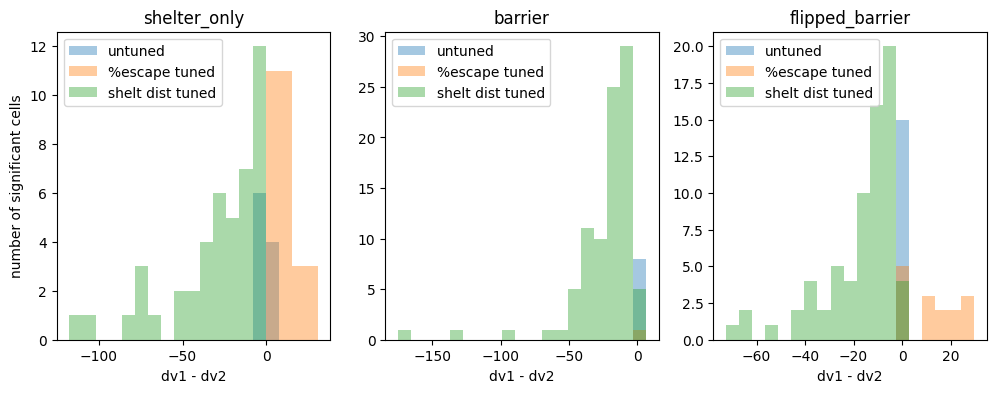

In [ ]:
"""Plot the distribution of difference between the distance between v1 and nh_given_v2 and between v2 and nh_given_v1
Show only the cells that are significantly tuned to %escape and shelter distance
Divide cells by whether tuned analysis classifies them as tuned to v1, v2 or undecided"""

c_names = ['shelter_only', 'barrier', 'flipped_barrier']
fig, axs = plt.subplots(1,3,figsize = (12,4))
for c in range(3):
    goodones = np.where(np.logical_and(exp_sig_cells[:,c], sig_cells[:,c]))[0]
    diff_this_c = dv1_minus_dv2[goodones,c]
    lower_percentile, upper_percentile = np.percentile(dv1_minus_dv2_dist[:,c,goodones], [2.5, 97.5], axis = 0)
    v1_sig = (lower_percentile > 0) & (upper_percentile > 0)
    v2_sig = (lower_percentile < 0) & (upper_percentile < 0)
    untuned = ~v1_sig & ~v2_sig
    axs[c].hist(diff_this_c[untuned], bins = np.arange(np.amin(diff_this_c), np.amax(diff_this_c), (np.amax(diff_this_c)-np.amin(diff_this_c))/20), label = r'untuned', alpha = .4)
    axs[c].hist(diff_this_c[v1_sig], bins = np.arange(np.amin(diff_this_c), np.amax(diff_this_c), (np.amax(diff_this_c)-np.amin(diff_this_c))/20), label = r'%escape tuned', alpha = .4)
    axs[c].hist(diff_this_c[v2_sig], bins = np.arange(np.amin(diff_this_c), np.amax(diff_this_c), (np.amax(diff_this_c)-np.amin(diff_this_c))/20), label = r'shelt dist tuned', alpha = .4)
    axs[c].legend()
    axs[c].set_xlabel('dv1 - dv2')
    axs[c].set_title(c_names[c])
axs[0].set_ylabel('number of significant cells')

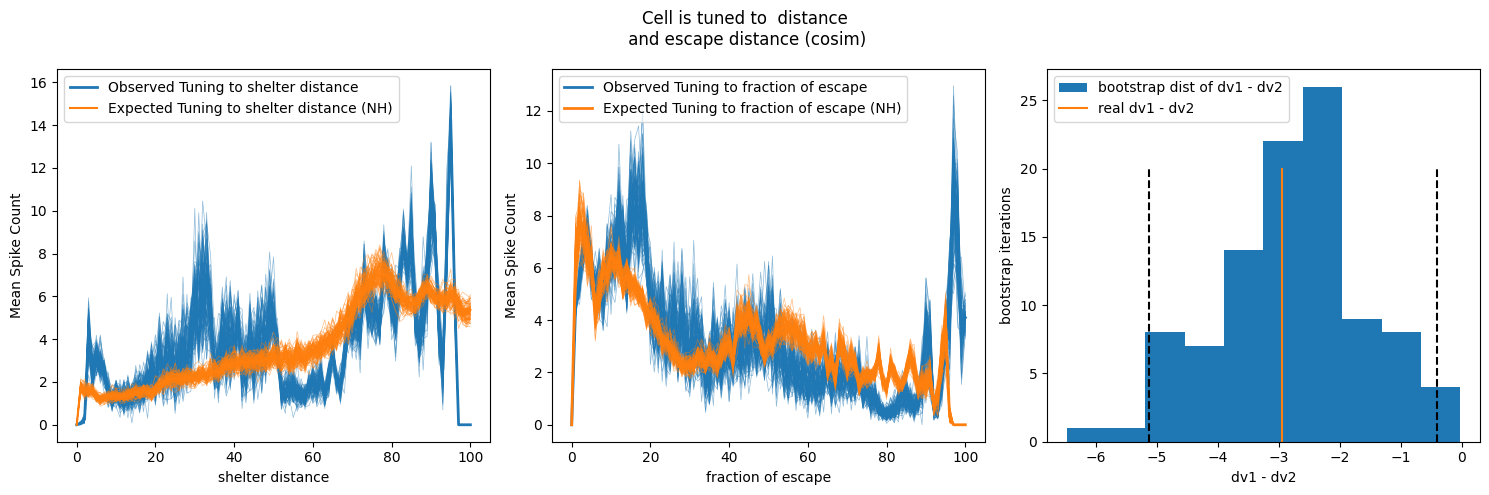

In [75]:
"""Plot LF method for tunED
If a cell is tuned to v1 (escape) then 
    - shifting v1 will cause a significant change in the number of different bins between the v1 observed tuning curve and the expected tuning curve based on v2
    - shifting v2 will not cause a significant change in the number of different bins between the v2 observed tuning curve and the expected tuning curve based on v1
Therefore if we shift v1, is_v1_sig will tell us whether to reject the v2 null hypothesis"""

# choose a cell to test
c = 0 # which condition do we want to look at
goodones = np.where(np.logical_and(exp_sig_cells[:,c], sig_cells[:,c]))[0]
idx = 2

# Step 1: Real Observed Tuning Curves and their variance

fig, axs = plt.subplots(1,3,figsize=(15,5))

# Plot Results v2
axs[0].plot(bin_edges[:-1], bs_dist[:, c, goodones[idx],:].T,linewidth = .5, alpha = .5, color = 'C0')
axs[0].plot(bin_edges[:-1], fr_dist[c, goodones[idx],:],linewidth = 2, label="Observed Tuning to shelter distance", color = 'C0')
axs[0].plot(bin_edges[:-1], mu_NH_v2_bs[:,goodones[idx],c,:].T,'C1',linewidth = .5, alpha = .5)
axs[0].plot(bin_edges[:-1], mu_NH_v2[goodones[idx],c,:], label="Expected Tuning to shelter distance (NH)", color='C1')
axs[0].set_xlabel("shelter distance")
axs[0].set_ylabel("Mean Spike Count")
axs[0].legend()

# Plot Results v1
axs[1].plot(bin_edges[:-1], bs_esc[:, c, goodones[idx],:].T,'C0',linewidth = .5, alpha = .5) # bootstrapped mu_v1
axs[1].plot(bin_edges[:-1], fr_esc[c, goodones[idx],:],'C0',linewidth = 2, label="Observed Tuning to fraction of escape")
axs[1].plot(bin_edges[:-1], mu_NH_v1_bs[:,goodones[idx],c,:].T,'C1',linewidth = .5, alpha = .5)
axs[1].plot(bin_edges[:-1], mu_NH_v1[goodones[idx],c,:],'C1',linewidth = 2, label="Expected Tuning to fraction of escape (NH)")
axs[1].set_xlabel("fraction of escape")
axs[1].set_ylabel("Mean Spike Count")
axs[1].legend()

# tuning decision based on euclidean distance
reject_v1_nh, reject_v2_nh = 'escape', 'distance'
lower_percentile, upper_percentile = np.percentile(dv1_minus_dv2_dist[:,c,goodones[idx]], [2.5, 97.5])
if lower_percentile < 0 and upper_percentile < 0:
    reject_v1_nh = '' # this mean that you can reject the null hypothesis that v1 is the driver, so the cell is tuned to v2
if lower_percentile > 0 and upper_percentile > 0:    
    reject_v2_nh = '' # this mean that you can reject the null hypothesis that v2 is the driver, so the cell is tuned to v1

# tuning decision based on cosine similarity
reject_v1_nh_cosim, reject_v2_nh_cosim = 'escape', 'distance'
lower_percentile, upper_percentile = np.percentile(cosim1_minus_cosim2_dist[:,c,goodones[idx]], [2.5, 97.5])
if lower_percentile > 0 and upper_percentile > 0:
    reject_v1_nh_cosim = '' # this mean that you can reject the null hypothesis that v1 is the driver, so the cell is tuned to v2
if lower_percentile < 0 and upper_percentile < 0:    
    reject_v2_nh_cosim = '' # this mean that you can reject the null hypothesis that v2 is the driver, so the cell is tuned to v1

Title = 'Cell is tuned to ' + reject_v1_nh + ' ' + reject_v2_nh + '\n and ' + reject_v1_nh_cosim + ' ' + reject_v2_nh_cosim + ' (cosim)'

fig.suptitle(Title)

lower_percentile, upper_percentile = np.percentile(dv1_minus_dv2_dist[:,c,goodones[idx]], [2.5, 97.5])
axs[2].hist(dv1_minus_dv2_dist[:,c,goodones[idx]], label = 'bootstrap dist of dv1 - dv2')
axs[2].plot([dv1_minus_dv2[goodones[idx],c],dv1_minus_dv2[goodones[idx],c]],[0,20], label = 'real dv1 - dv2')
axs[2].plot([lower_percentile,lower_percentile],[0,20],'--k')
axs[2].plot([upper_percentile,upper_percentile],[0,20],'--k')
axs[2].set_xlabel('dv1 - dv2')
axs[2].set_ylabel('bootstrap iterations')
axs[2].legend()

plt.tight_layout()
plt.show()

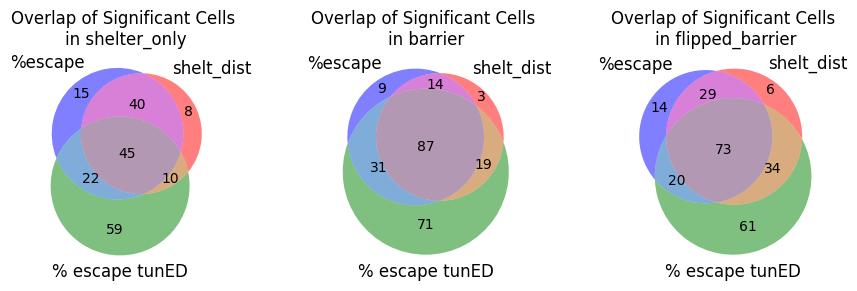

In [ ]:
"""Venn diagram"""

fig, axs = plt.subplots(1,3,figsize=(9, 3))
for c in range(3):
    diff_this_c = dv1_minus_dv2[:,c]
    dist_this_c = dv1_minus_dv2_dist[:,c,:]
    lower_percentile, upper_percentile = np.percentile(dist_this_c, [2.5, 97.5], axis = 0)
    v1_sig = (lower_percentile > 0) & (upper_percentile > 0)
    v2_sig = (lower_percentile < 0) & (upper_percentile < 0)
    # dist_this_c = cosim1_minus_cosim2_dist[:,c,:]
    # lower_percentile, upper_percentile = np.percentile(dist_this_c, [2.5, 97.5], axis = 0)
    # v1_sig = (lower_percentile < 0) & (upper_percentile < 0)
    # v2_sig = (lower_percentile > 0) & (upper_percentile > 0)
    untuned = ~v1_sig & ~v2_sig
    third = v2_sig
    # Compute Set Sizes
    A = np.sum((sig_cells[:, c] == True) & (exp_sig_cells[:, c] == False) & (third == False))  # V1 only
    B = np.sum((sig_cells[:, c] == False) & (exp_sig_cells[:, c] == True) & (third == False))  # V2 only
    C = np.sum((sig_cells[:, c] == False) & (exp_sig_cells[:, c] == False) & (third == True))  # V1 regressed
    AB = np.sum((sig_cells[:, c] == True) & (exp_sig_cells[:, c] == True) & (third == False))  # Both V1 and V2
    AC = np.sum((sig_cells[:, c] == True) & (exp_sig_cells[:, c] == False) & (third == True))  # Both V1 and V1 regressed
    BC = np.sum((sig_cells[:, c] == False) & (exp_sig_cells[:, c] == True) & (third == True))  # Both V2 and V1 regressed
    ABC = np.sum((sig_cells[:, c] == True) & (exp_sig_cells[:, c] == True) & (third == True))  # All three

    # Create Venn Diagram
    venn3(subsets=(A, B, AB, C, AC, BC, ABC), 
        set_labels=(r'%escape', 'shelt_dist', r'% escape tunED'), 
        set_colors=('blue', 'red', 'green'),
        alpha=0.5,
        ax=axs[c])
    axs[c].set_title('Overlap of Significant Cells \nin ' + c_names[c])
plt.tight_layout()

In [ ]:
"""Venn diagram"""

fig, axs = plt.subplots(1,3,figsize=(9, 3))
for c in range(3):
    diff_this_c = dv1_minus_dv2[:,c]
    dist_this_c = dv1_minus_dv2_dist[:,c,:]
    lower_percentile, upper_percentile = np.percentile(dist_this_c, [2.5, 97.5], axis = 0)
    v1_sig = (lower_percentile > 0) & (upper_percentile > 0)
    v2_sig = (lower_percentile < 0) & (upper_percentile < 0)
    untuned = ~v1_sig & ~v2_sig
    third = v1_sig
    # Compute Set Sizes
    A = np.sum((sig_cells[:, c] == True) & (exp_sig_cells[:, c] == False) & (third == False))  # V1 only
    B = np.sum((sig_cells[:, c] == False) & (exp_sig_cells[:, c] == True) & (third == False))  # V2 only
    C = np.sum((sig_cells[:, c] == False) & (exp_sig_cells[:, c] == False) & (third == True))  # V1 regressed
    AB = np.sum((sig_cells[:, c] == True) & (exp_sig_cells[:, c] == True) & (third == False))  # Both V1 and V2
    AC = np.sum((sig_cells[:, c] == True) & (exp_sig_cells[:, c] == False) & (third == True))  # Both V1 and V1 regressed
    BC = np.sum((sig_cells[:, c] == False) & (exp_sig_cells[:, c] == True) & (third == True))  # Both V2 and V1 regressed
    ABC = np.sum((sig_cells[:, c] == True) & (exp_sig_cells[:, c] == True) & (third == True))  # All three

    # Create Venn Diagram
    venn3(subsets=(A, B, AB, C, AC, BC, ABC), 
        set_labels=(r'%escape', 'shelt_dist', r'% escape tunED'), 
        set_colors=('blue', 'red', 'green'),
        alpha=0.5,
        ax=axs[c])
    axs[c].set_title('Overlap of Significant Cells \nin ' + c_names[c])
plt.tight_layout()

In [ ]:
"""Plot the conditional probabilities of the behaviors"""
fig, axs = plt.subplots(1,2,figsize=(10,5))

cb = axs[0].imshow(p_v1_given_v2, cmap="Blues", aspect="auto")
axs[0].set_xlabel("v1 values")
axs[0].set_ylabel("v2 values")
fig.colorbar(cb, ax=axs[0], location='right', anchor=(0, 0.3), shrink=0.7)
axs[0].set_title("Estimated P(v1 | v2) using Discrete Bins")

cb = axs[1].imshow(p_v2_given_v1, cmap="Blues", aspect="auto")
axs[1].set_xlabel("v1 values")
axs[1].set_ylabel("v2 values")
fig.colorbar(cb, ax=axs[1], location='right', anchor=(0, 0.3), shrink=0.7)
axs[1].set_title("Estimated P(v1 | v2) using Discrete Bins")